##1. Импорт библиотек

In [1]:
import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, label_binarize

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import (
    BatchNormalization,
    Conv1D,
    Dense,
    Dropout,
    Flatten,
    GRU,
    Input,
    MaxPooling1D
)
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

warnings.filterwarnings('ignore')

In [2]:
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

##2. Загрузка данных

In [3]:
# Загрузка данных с GitHub
csv_url = "https://raw.githubusercontent.com/Daria-Chernykh/iad-course-project/main/MKA_04.2015_unlabeled.csv"
df_features = pd.read_csv(csv_url)

xls_url = "https://raw.githubusercontent.com/Daria-Chernykh/iad-course-project/main/MKA_TMI_labels.xls"
df_labels = pd.read_excel(xls_url)

print("Размер df_features:", df_features.shape)
print("Размер df_labels:", df_labels.shape)

Размер df_features: (15243, 49)
Размер df_labels: (2679, 50)


##3. Первичный анализ данных

###3.1 Просмотр первых строк

In [4]:
print("Первые строки df_features:")
display(df_features.head())

print("\nПервые строки df_labels:")
display(df_labels.head())

Первые строки df_features:


,"Ubs,V","Ibs,A","Isun,A","Ipt1,A","Ipt2,A","Ipt3,A","Ipt4,A","Ipt5,A","Ipt6,A","Ipt7,A","Ipt10,A","Ipt11,A","Ipt12,A","Ipt13,A","Ipt14,A","Ipt15,A","Ipt16,A","Ipt17,A","TR1,C","TR2,C","TR3,C","TR4,C","TR5,C","TR6,C","TR7,C","TR8,C","TR9,C","TR10,C","TR11,C","TR12,C","TR13,C","TR14,C","TR15,C","TR16,C","TDS1,C","TDS2,C","TDS3,C","TDS4,C","TDS5,C","TDS6,C","TDS7,C","TDS8,C","TDS9,C","TKpt,C","TGbv,C","TNap,C","TPrd2,C","TPrd1,C","TDS24,C"
0,13.12,1.41,0.99,0.07,1.13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,22.0,4.0,2.0,3.0,5.0,1.0,1.0,0.0,-1.0,-17.0,6.0,2.0,6.0,2.0,3.0,16.0,16.0,16.0,16.0,16.0,15.0,20.0,19.0,18.0,26.0,20.0,19.0,30.0,20.0,21.0
1,13.12,1.44,1.09,0.07,1.20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,22.0,4.0,2.0,4.0,5.0,2.0,2.0,0.0,-1.0,-17.0,9.0,2.0,6.0,4.0,2.0,16.0,16.0,16.0,16.0,16.0,15.0,21.0,20.0,18.0,26.0,20.0,19.0,31.0,20.0,21.0
2,13.25,0.27,1.44,0.09,0.07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,24.0,4.0,2.0,4.0,5.0,2.0,2.0,1.0,-1.0,-12.0,9.0,4.0,8.0,4.0,5.0,16.0,16.0,16.0,16.0,16.0,15.0,21.0,20.0,18.0,26.0,20.0,19.0,31.0,20.0,21.0
3,13.32,0.27,0.88,0.07,0.07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,24.0,4.0,2.0,4.0,5.0,2.0,2.0,1.0,0.0,-9.0,8.0,4.0,8.0,5.0,5.0,16.0,16.0,16.0,16.0,16.0,15.0,21.0,20.0,19.0,26.0,20.0,19.0,27.0,20.0,21.0
4,13.38,0.21,0.80,0.09,0.07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,24.0,4.0,4.0,4.0,5.0,4.0,4.0,1.0,0.0,-9.0,9.0,2.0,9.0,5.0,5.0,15.0,16.0,16.0,16.0,16.0,15.0,20.0,20.0,19.0,26.0,20.0,19.0,25.0,20.0,21.0



Первые строки df_labels:


,"Ubs,V","Ibs,A","Isun,A","Ipt1,A","Ipt2,A","Ipt3,A","Ipt4,A","Ipt5,A","Ipt6,A","Ipt7,A","Ipt10,A","Ipt11,A","Ipt12,A","Ipt13,A","Ipt14,A","Ipt15,A","Ipt16,A","Ipt17,A","TR1,C","TR2,C","TR3,C","TR4,C","TR5,C","TR6,C","TR7,C","TR8,C","TR9,C","TR10,C","TR11,C","TR12,C","TR13,C","TR14,C","TR15,C","TR16,C","TDS1,C","TDS2,C","TDS3,C","TDS4,C","TDS5,C","TDS6,C","TDS7,C","TDS8,C","TDS9,C","TKpt,C","TGbv,C","TNap,C","TPrd2,C","TPrd1,C","TDS24,C",Class
0,14.83,0.24,0.91,0.09,0.07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21,19,16,14,6,8,14,17,13,11,25.0,9,17,19,18,19,18,18,18,18,18,18,17,17,17,25,17,16,18,18,21,0
1,14.76,0.21,0.27,0.07,0.07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21,20,16,15,6,8,14,17,13,12,25.0,9,17,20,18,19,18,18,18,18,18,18,17,17,17,25,17,16,18,18,21,0
2,14.83,0.24,0.61,0.09,0.07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21,19,16,15,6,10,14,17,14,12,25.0,11,17,20,20,18,18,18,18,18,18,18,17,17,17,25,17,17,18,18,21,0
3,14.83,0.21,0.51,0.07,0.07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21,19,17,15,7,10,14,17,14,12,22.0,11,18,20,20,19,18,18,18,18,18,18,17,17,17,25,17,17,18,18,21,0
4,14.83,0.21,0.35,0.07,0.09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21,19,17,15,7,10,15,17,14,13,24.0,11,18,20,20,21,18,18,18,18,18,18,18,18,17,25,17,17,18,18,21,0


По результатам просмотра первых строк можно сделать следующие выводы:
- Данные представляют собой числовые признаки телеметрии малого космического аппарата (ТМИ).
- Названия признаков имеют инженерный характер (например, Ubs_V, Ibs_A, TR1_C и т.д.), что соответствует показаниям различных датчиков.
- В наборе df_features отсутствует столбец с метками классов — это неразмеченные данные.
- В наборе df_labels присутствуют те же признаки, а также дополнительный столбец **Class**, который содержит метки классов.
- Структура признаков в df_features и df_labels совпадает (одинаковые названия столбцов признаков).
- Значения признаков имеют различный масштаб (например, напряжения, токи, температуры), что требует последующей нормализации или стандартизации.

Таким образом, df_labels содержит размеченную часть данных, а df_features — полный (в том числе неразмеченный) набор телеметрии.

###3.2 Информация о данных

In [5]:
print("Информация о df_features:")
df_features.info()

print("\nИнформация о df_labels:")
df_labels.info()

Информация о df_features:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15243 entries, 0 to 15242
Data columns (total 49 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ubs,V    15243 non-null  float64
 1   Ibs,A    15243 non-null  float64
 2   Isun,A   15243 non-null  float64
 3   Ipt1,A   15243 non-null  float64
 4   Ipt2,A   15243 non-null  float64
 5   Ipt3,A   15243 non-null  float64
 6   Ipt4,A   15243 non-null  float64
 7   Ipt5,A   15243 non-null  float64
 8   Ipt6,A   15243 non-null  float64
 9   Ipt7,A   15243 non-null  float64
 10  Ipt10,A  15243 non-null  float64
 11  Ipt11,A  15243 non-null  float64
 12  Ipt12,A  15243 non-null  float64
 13  Ipt13,A  15243 non-null  float64
 14  Ipt14,A  15243 non-null  float64
 15  Ipt15,A  15243 non-null  float64
 16  Ipt16,A  15243 non-null  float64
 17  Ipt17,A  15243 non-null  float64
 18  TR1,C    15243 non-null  float64
 19  TR2,C    15243 non-null  float64
 20  TR3,C    15243 non-null 

### Вывод по информации о данных
- Размер набора df_features: 15243 объектов и 49 признаков.
- Размер набора df_labels: 2679 объектов и 50 столбцов (49 признаков + 1 целевой признак Class).
- Все признаки в df_features имеют тип float64, пропуски отсутствуют.
- В df_labels признаки представлены типами float64 и int64, также отсутствуют пропуски.
- Столбец Class в df_labels является целевым признаком и содержит целочисленные метки классов.
- Количество объектов в df_labels значительно меньше, чем в df_features, что указывает на наличие неразмеченных данных.

Таким образом:
- df_labels — размеченная подвыборка данных;
- df_features — полный набор, содержащий как размеченные, так и неразмеченные данные.

Это подтверждает постановку задачи с частично размеченными данными, где неразмеченная часть будет использоваться для предобучения (автокодировщик), а размеченная — для обучения классификатора.

###3.3 Проверка пропусков

In [6]:
print("Пропуски в df_features:")
print(df_features.isna().sum())

print("\nПропуски в df_labels:")
print(df_labels.isna().sum())

Пропуски в df_features:
Ubs,V      0
Ibs,A      0
Isun,A     0
Ipt1,A     0
Ipt2,A     0
Ipt3,A     0
Ipt4,A     0
Ipt5,A     0
Ipt6,A     0
Ipt7,A     0
Ipt10,A    0
Ipt11,A    0
Ipt12,A    0
Ipt13,A    0
Ipt14,A    0
Ipt15,A    0
Ipt16,A    0
Ipt17,A    0
TR1,C      0
TR2,C      0
TR3,C      0
TR4,C      0
TR5,C      0
TR6,C      0
TR7,C      0
TR8,C      0
TR9,C      0
TR10,C     0
TR11,C     0
TR12,C     0
TR13,C     0
TR14,C     0
TR15,C     0
TR16,C     0
TDS1,C     0
TDS2,C     0
TDS3,C     0
TDS4,C     0
TDS5,C     0
TDS6,C     0
TDS7,C     0
TDS8,C     0
TDS9,C     0
TKpt,C     0
TGbv,C     0
TNap,C     0
TPrd2,C    0
TPrd1,C    0
TDS24,C    0
dtype: int64

Пропуски в df_labels:
Ubs,V      0
Ibs,A      0
Isun,A     0
Ipt1,A     0
Ipt2,A     0
Ipt3,A     0
Ipt4,A     0
Ipt5,A     0
Ipt6,A     0
Ipt7,A     0
Ipt10,A    0
Ipt11,A    0
Ipt12,A    0
Ipt13,A    0
Ipt14,A    0
Ipt15,A    0
Ipt16,A    0
Ipt17,A    0
TR1,C      0
TR2,C      0
TR3,C      0
TR4,C      0
TR5,C      0
TR6,

Проверка данных показала, что:

- В наборе df_features отсутствуют пропущенные значения.
- В наборе df_labels также отсутствуют пропущенные значения.

Таким образом, этап обработки пропусков не требуется, что упрощает дальнейшую предобработку данных.

###3.4 Анализ распределения классов

Уникальные классы:
[0 2 1]

Распределение классов:


,count
Class,
0,2356
1,218
2,105


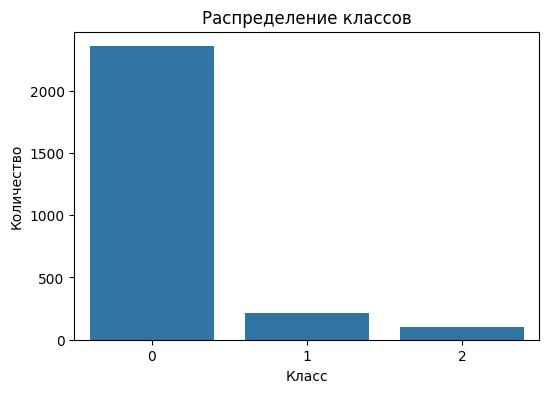

In [7]:
label_column = 'Class'

print("Уникальные классы:")
print(df_labels[label_column].unique())

print("\nРаспределение классов:")
display(df_labels[label_column].value_counts())

# Визуализация
plt.figure(figsize=(6,4))
sns.countplot(x=df_labels[label_column])
plt.title("Распределение классов")
plt.xlabel("Класс")
plt.ylabel("Количество")
plt.show()

Анализ распределения классов показал:

- В данных присутствуют три класса:
  - 0 — штатное функционирование,
  - 1 — отказ,
  - 2 — сбой.

- Распределение классов:
  - класс 0: 2356 объектов,
  - класс 1: 218 объектов,
  - класс 2: 105 объектов.

- Наблюдается сильный дисбаланс классов:
  - класс 0 существенно преобладает,
  - классы 1 и 2 представлены значительно меньшим количеством наблюдений.

Таким образом, задача является несбалансированной классификацией.

В связи с этим при обучении моделей необходимо:
- использовать дополнительные метрики качества (balanced accuracy, F1-score, ROC-AUC),
- учитывать влияние дисбаланса на обучение модели.

Также на этапе моделирования возможно применение методов борьбы с дисбалансом (например, взвешивание классов или ресемплирование).

###3.5 Описательная статистика признаков

In [8]:
display(df_features.describe())

,"Ubs,V","Ibs,A","Isun,A","Ipt1,A","Ipt2,A","Ipt3,A","Ipt4,A","Ipt5,A","Ipt6,A","Ipt7,A","Ipt10,A","Ipt11,A","Ipt12,A","Ipt13,A","Ipt14,A","Ipt15,A","Ipt16,A","Ipt17,A","TR1,C","TR2,C","TR3,C","TR4,C","TR5,C","TR6,C","TR7,C","TR8,C","TR9,C","TR10,C","TR11,C","TR12,C","TR13,C","TR14,C","TR15,C","TR16,C","TDS1,C","TDS2,C","TDS3,C","TDS4,C","TDS5,C","TDS6,C","TDS7,C","TDS8,C","TDS9,C","TKpt,C","TGbv,C","TNap,C","TPrd2,C","TPrd1,C","TDS24,C"
count,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000,15243.000000
mean,14.305320,0.390855,0.512884,0.124092,0.163564,0.041040,0.035418,0.033457,0.097352,0.048206,0.035278,0.042574,0.042553,0.035927,0.044939,0.045727,0.034606,0.049496,15.745063,17.111723,7.447878,3.808437,4.423211,8.796366,4.181198,6.601850,5.569179,2.994752,-8.377222,8.915109,6.522141,9.133110,10.905202,5.235780,15.235124,15.359969,14.974677,14.855081,15.297907,14.844191,14.188546,14.050449,14.082792,23.321393,14.409106,14.378862,16.083973,16.763367,21.642065
std,0.984177,0.591637,0.682362,0.384701,0.438473,0.360275,0.333368,0.339513,0.489494,0.467448,0.344907,0.439390,0.433646,0.350609,0.450163,0.446794,0.335203,0.457572,35.385938,24.907324,24.566440,34.946630,31.280534,20.880525,29.793943,24.884574,26.445962,29.745716,33.905844,31.262559,26.934586,26.397302,19.920235,33.748501,16.805430,15.065286,19.182386,21.172074,19.118255,18.994044,20.681500,22.395249,21.660678,20.582956,22.753831,22.485148,20.071795,14.411778,10.728922
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-257.000000,-257.000000,-235.000000,-236.000000,-235.000000,-236.000000,-236.000000,-236.000000,-235.000000,-236.000000,-257.000000,-257.000000,-257.000000,-257.000000,-257.000000,-256.000000,-128.000000,-128.000000,-128.000000,-128.000000,-128.000000,-128.000000,-128.000000,-128.000000,-128.000000,-128.000000,-128.000000,-128.000000,-128.000000,-128.000000,-128.000000
25%,14.240000,0.210000,0.000000,0.070000,0.070000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,19.000000,6.000000,5.000000,6.000000,7.000000,2.000000,4.000000,4.000000,2.000000,-28.000000,9.000000,4.000000,6.000000,5.000000,3.000000,17.000000,17.000000,17.000000,17.000000,17.000000,16.000000,16.000000,16.000000,16.000000,26.000000,17.000000,17.000000,17.000000,17.000000,21.000000
50%,14.560000,0.240000,0.270000,0.070000,0.070000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,21.000000,20.000000,10.000000,10.000000,9.000000,11.000000,8.000000,10.000000,9.000000,8.000000,-1.000000,12.000000,10.000000,12.000000,12.000000,10.000000,17.000000,17.000000,17.000000,18.000000,18.000000,17.000000,17.000000,18.000000,17.000000,26.000000,18.000000,18.000000,19.000000,19.000000,22.000000
75%,14.690000,0.240000,0.880000,0.090000,0.090000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,21.000000,22.000000,14.000000,14.000000,13.000000,15.000000,14.000000,15.000000,14.000000,12.000000,14.000000,17.000000,15.000000,19.000000,17.000000,16.000000,18.000000,18.000000,18.000000,19.000000,19.000000,18.000000,19.000000,19.000000,19.000000,27.000000,19.000000,19.000000,20.000000,20.000000,22.000000
max,15.610000,6.4500

Анализ статистических характеристик признаков показал:

- Все признаки являются числовыми и имеют различный масштаб значений.
- Значения признаков существенно различаются по диапазону:
  - часть признаков принимает значения, близкие к нулю,
  - часть — значения порядка десятков и сотен.
- Для ряда признаков наблюдаются отрицательные значения (например, минимальные значения до -257 и -128), что может быть связано с особенностями кодирования телеметрии.
- Средние значения и стандартные отклонения значительно различаются между признаками, что подтверждает разнородность данных (разные физические величины: токи, напряжения, температуры и др.).

Таким образом, признаки имеют различный масштаб и распределение, что требует обязательного применения методов масштабирования (например, стандартизации или нормализации) перед обучением нейросетевых моделей.

###3.6 Визуализация распределений признаков

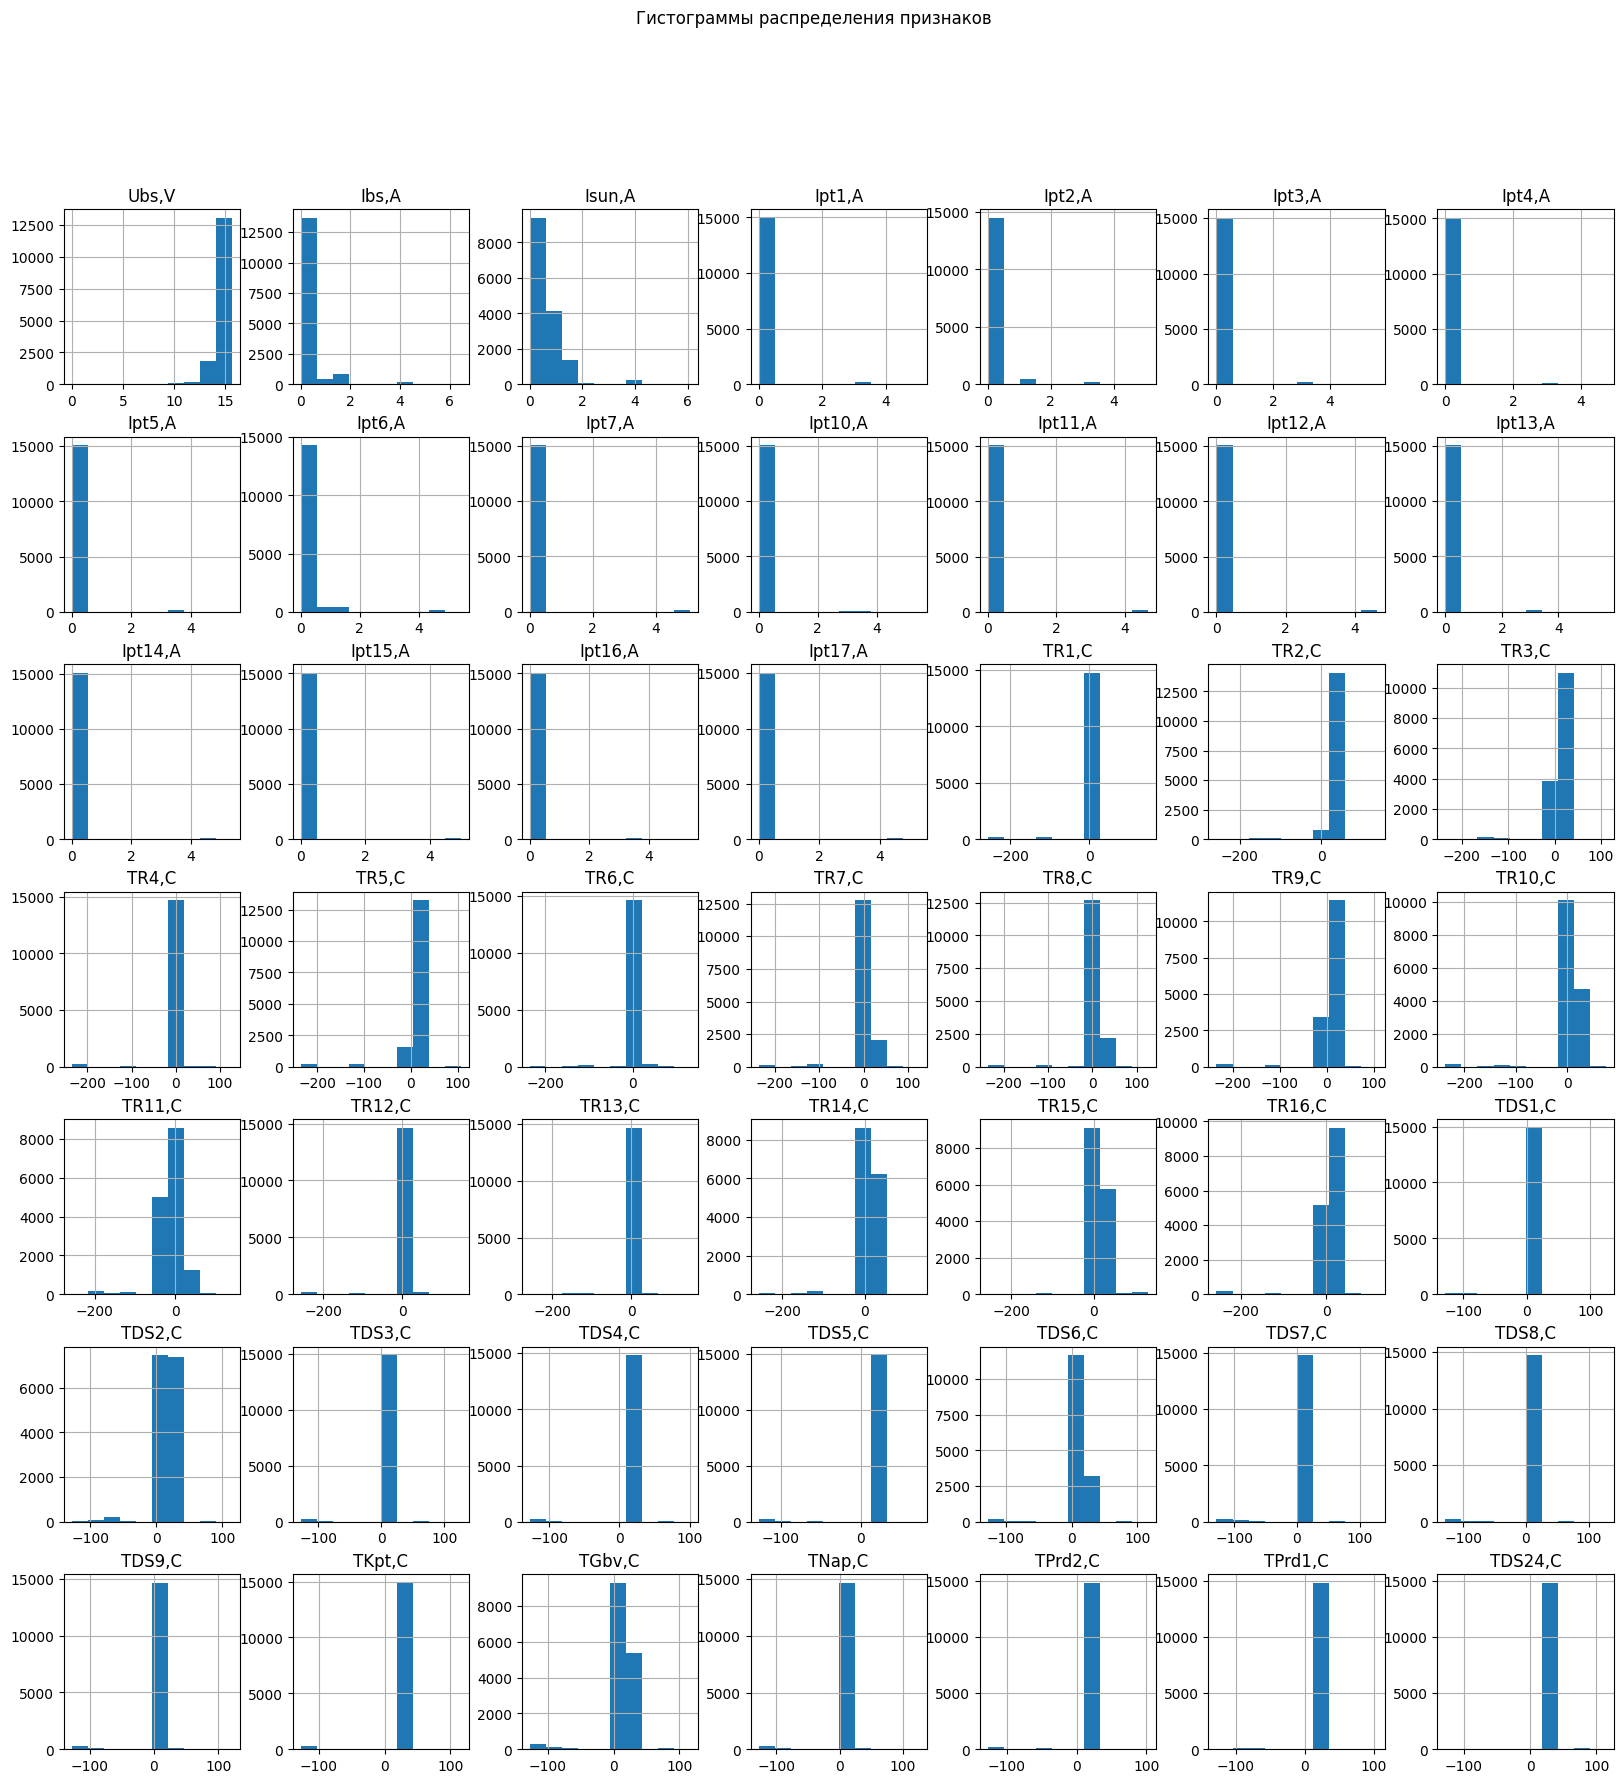

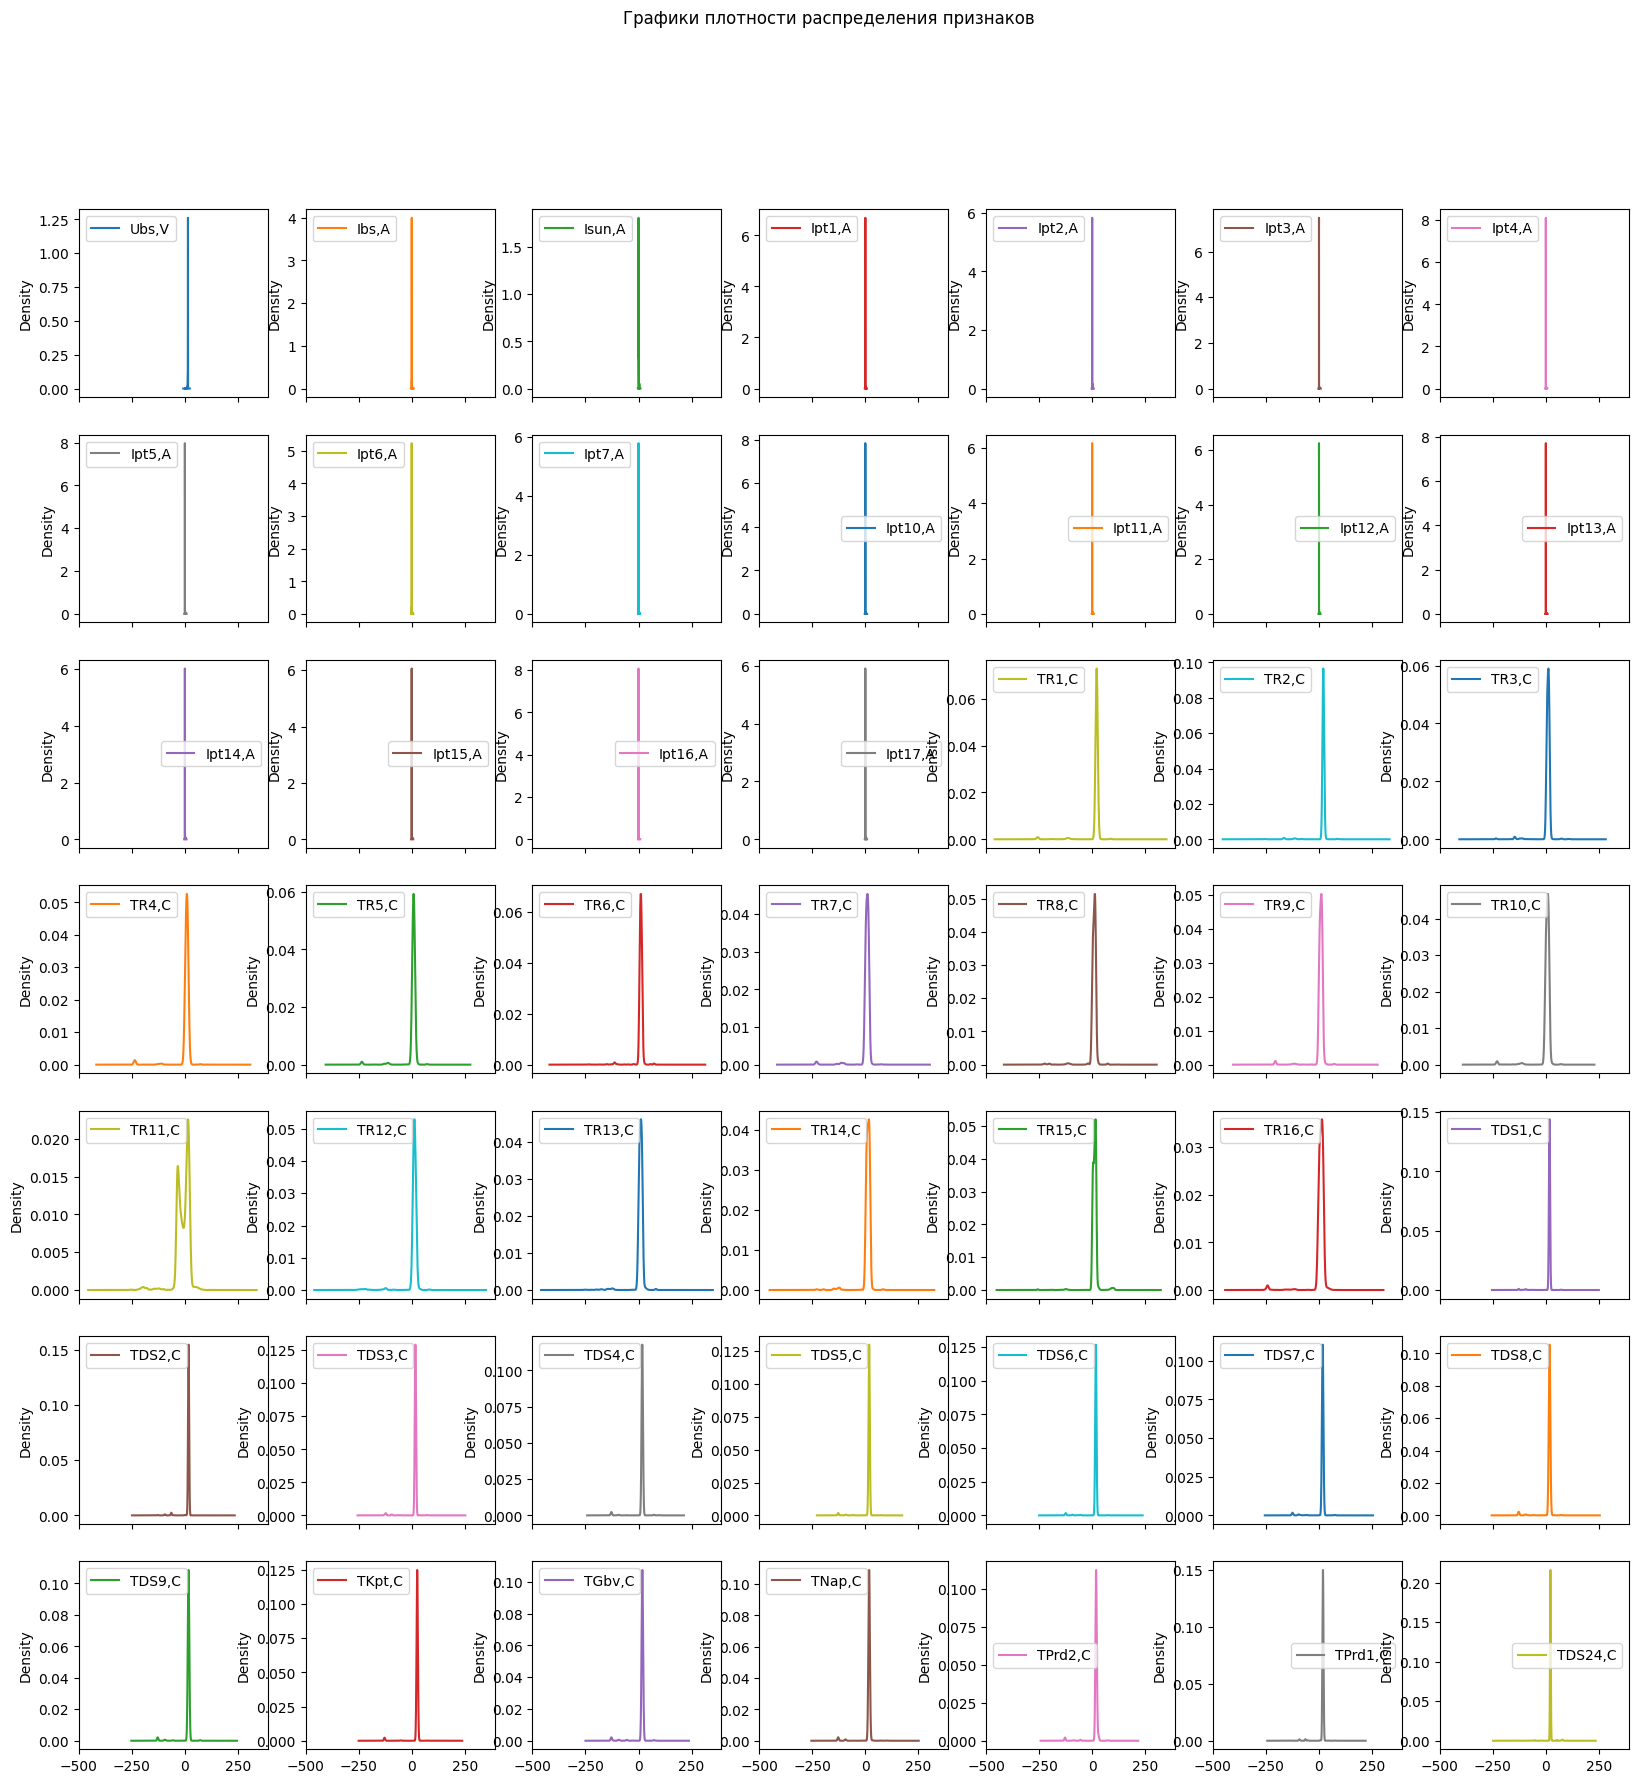

In [9]:
# Гистограммы
df_features.hist(figsize=(20,20))
plt.suptitle("Гистограммы распределения признаков")
plt.show()

# Графики плотности
df_features.plot(kind='density', subplots=True, layout=(7,7), figsize=(20,20))
plt.suptitle("Графики плотности распределения признаков")
plt.show()

Анализ гистограмм и графиков плотности показал:

- Большинство признаков имеют сильно скошенные распределения:
  - наблюдается высокая концентрация значений вблизи нуля,
  - при этом присутствуют редкие большие значения (выбросы).
- Для ряда признаков распределения имеют дискретный характер, что может быть связано с особенностями измерения или квантованием сигналов.
- На графиках плотности заметны узкие пики, что указывает на повторяющиеся значения и возможные фиксированные режимы работы системы.
- В некоторых признаках присутствуют аномальные значения (например, около -250 и -130), которые могут соответствовать специальным кодам (например, отсутствие сигнала или ошибка датчика).

Таким образом, распределения признаков являются неоднородными, содержат выбросы и не соответствуют нормальному распределению, что необходимо учитывать при предобработке данных.

###3.7 Корреляционный анализ

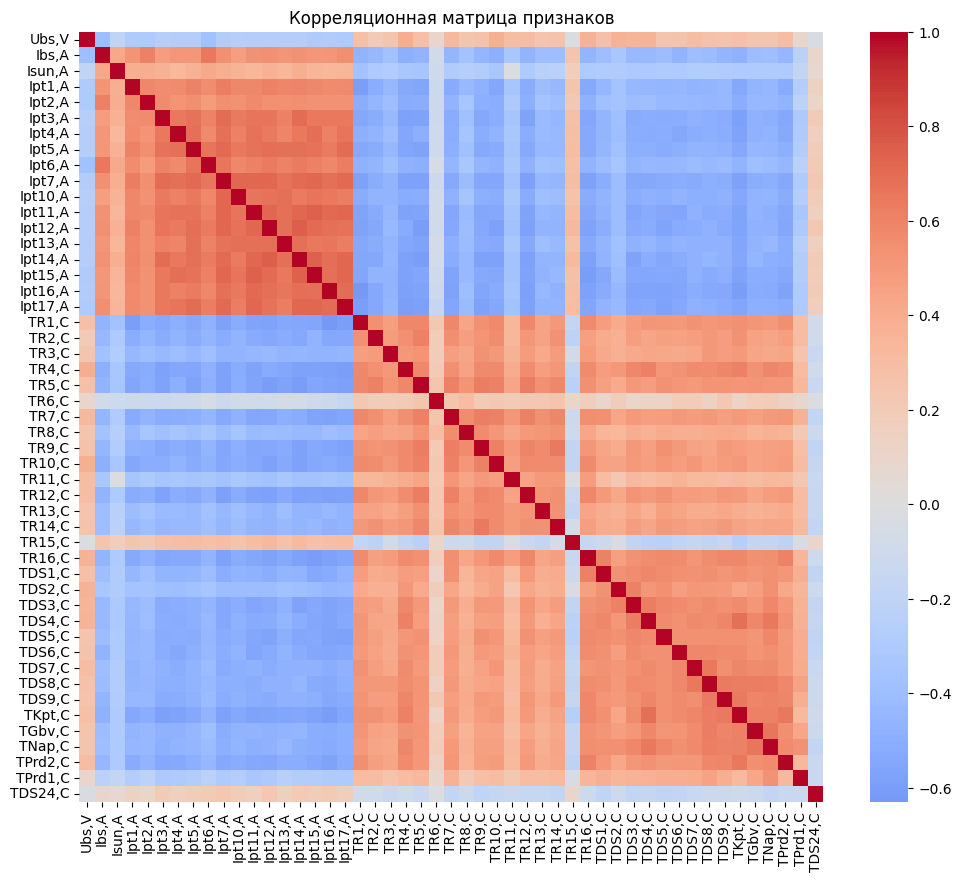

In [10]:
plt.figure(figsize=(12,10))
corr_matrix = df_features.corr()
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Корреляционная матрица признаков")
plt.show()

Анализ корреляционной матрицы показал:

- Признаки можно условно разделить на несколько групп с высокой внутригрупповой корреляцией.
- Внутри отдельных групп признаков наблюдается высокая положительная корреляция (значения близки к 1), что указывает на сильную взаимосвязь между соответствующими параметрами телеметрии.
- Между различными группами признаков наблюдается отрицательная или слабая корреляция, что свидетельствует о различной природе измеряемых процессов.
- Наличие выраженной блочной структуры корреляционной матрицы указывает на то, что признаки отражают разные подсистемы космического аппарата (например, электрические параметры, температурные характеристики и др.).
- Высокая корреляция между признаками может приводить к избыточности информации.

Таким образом, данные обладают выраженной структурой зависимостей между признаками. Несмотря на наличие коррелированных признаков, для нейросетевых моделей это не является критическим ограничением, так как они способны автоматически извлекать значимые зависимости из данных.

###3.8 Корреляция с целевым признаком

In [11]:
corr_with_target = df_labels.corr()['Class'].sort_values(ascending=False)
display(corr_with_target)

,Class
Class,1.000000
"Ipt1,A",0.520780
"Ipt3,A",0.485096
"Ipt16,A",0.480947
"Ipt4,A",0.476128
"Ipt7,A",0.475100
"Ipt14,A",0.473560
"Ipt17,A",0.471052
"Ipt2,A",0.469668
"Ipt11,A",0.468986


Анализ корреляции признаков с целевым признаком показал:

- Наиболее сильную положительную корреляцию с целевым признаком имеют признаки:
  - Ipt1_A (≈ 0.52),
  - Ipt3_A (≈ 0.49),
  - Ipt16_A (≈ 0.48),
  - Ipt4_A, Ipt7_A, Ipt14_A (≈ 0.47).

- Эти признаки относятся к группе токов (обозначение Ipt), что указывает на их значимую роль в определении технического состояния аппарата.

- Значительная часть признаков имеет отрицательную корреляцию с целевым признаком:
  - например, TR7_C (≈ -0.61),
  - TR5_C, TR12_C, TR13_C (≈ -0.60),
  - TR10_C (≈ -0.57).

- Эти признаки, вероятно, относятся к температурным параметрам, что также свидетельствует об их влиянии на состояние системы.

- В целом наблюдается умеренная корреляция признаков с целевым признаком (|r| < 0.7), что указывает на отсутствие сильной линейной зависимости.

Таким образом, зависимость между признаками и целевым признаком является сложной и нелинейной, что обосновывает использование нейросетевых моделей для решения задачи классификации.

##4. Подготовка размеченного набора

###4.1 Выделение признаков и целевой переменной

In [12]:
X_labeled = df_labels.drop(columns=['Class'])
y_labeled = df_labels['Class']

print("Размер X_labeled:", X_labeled.shape)
print("Размер y_labeled:", y_labeled.shape)

Размер X_labeled: (2679, 49)
Размер y_labeled: (2679,)


Размеченный набор данных сформирован на основе df_labels.

- В качестве признаков используется матрица X_labeled, содержащая все признаки телеметрии.
- В качестве целевой переменной используется столбец Class (y_labeled).

Размер размеченного набора:
- X_labeled: 2679 объектов и 49 признаков,
- y_labeled: 2679 меток классов.

###4.2 Проверка структуры признаков

In [13]:
print("Совпадают ли признаки:", list(X_labeled.columns) == list(df_features.columns))

Совпадают ли признаки: True


Проверка показала, что структура признаков в df_labels и df_features совпадает.

Это означает, что оба набора данных описывают объекты одной природы (телеметрические параметры).

##5. Подготовка неразмеченного набора

In [14]:
X_unlabeled = df_features.copy()
print("Размер X_unlabeled:", X_unlabeled.shape)

Размер X_unlabeled: (15243, 49)


Неразмеченный набор данных сформирован на основе df_features.

Он содержит полный набор телеметрических данных (15243 объекта) без меток классов.

Данный набор будет использоваться для предобучения автокодировщика.

##6. Предобработка данных

###6.1 Анализ аномальных значений

In [15]:
anomaly_threshold = -100

anomaly_counts = (X_labeled < anomaly_threshold).sum()
anomaly_counts = anomaly_counts[anomaly_counts > 0]

print("Признаки с аномальными значениями:")
display(anomaly_counts)

Признаки с аномальными значениями:


,0
"TR1,C",204
"TR2,C",184
"TR3,C",190
"TR4,C",218
"TR5,C",223
"TR6,C",179
"TR7,C",224
"TR8,C",52
"TR9,C",198
"TR10,C",213


В данных обнаружены признаки, содержащие значения значительно ниже типичных диапазонов (например, -128, -257).

Такие значения не являются случайными выбросами, а обусловлены особенностями телеметрических данных и, вероятно, соответствуют:
- отсутствию сигнала,
- ошибкам датчиков,
- специальным кодам состояния системы.

Наличие подобных значений характерно для телеметрических систем и несёт важную диагностическую информацию.

В данной работе принято решение не выполнять замену или удаление аномальных значений.

Это обусловлено тем, что:
- аномальные значения являются частью системы кодирования телеметрии;
- они могут напрямую соответствовать аварийным или переходным состояниям;
- удаление или замена таких значений приведёт к потере важной информации.

Таким образом, все исходные значения признаков сохраняются без изменений.

###6.2 Подготовка данных к дальнейшей обработке

In [16]:
X_labeled_prepared = X_labeled.copy()
X_unlabeled_prepared = X_unlabeled.copy()

print("Размер X_labeled_prepared:", X_labeled_prepared.shape)
print("Размер X_unlabeled_prepared:", X_unlabeled_prepared.shape)

Размер X_labeled_prepared: (2679, 49)
Размер X_unlabeled_prepared: (15243, 49)


Для дальнейшей работы сформированы подготовленные наборы данных:

- X_labeled_prepared — размеченный набор данных;
- X_unlabeled_prepared — неразмеченный набор данных.

На данном этапе данные не подвергались изменению значений признаков.

###6.3 Выбор метода преобразования данных

Признаки имеют различные диапазоны значений и различную природу.

Для корректного обучения нейросетевых моделей необходимо привести признаки к сопоставимому масштабу.

В качестве метода преобразования выбран StandardScaler (стандартизация), так как:
- он центрирует данные и приводит их к единичной дисперсии;
- хорошо подходит для нейросетевых моделей;
- сохраняет структуру зависимостей между признаками.

Во избежание утечки данных обучение масштабировщика будет выполняться только на обучающей выборке после разделения данных на train, validation и test.

###6.4 Формирование исходного и преобразованного наборов данных

В рамках данной работы будут использоваться два варианта данных:

1. Исходный набор данных:
   - X_labeled_prepared и X_unlabeled_prepared;
   - содержит реальные значения телеметрии без масштабирования.

2. Преобразованный набор данных:
   - будет получен с использованием стандартизации (StandardScaler);
   - формируется после разбиения данных на обучающую, валидационную и тестовую выборки.

Сравнение качества моделей на этих двух вариантах позволит оценить влияние масштабирования на точность классификации.

##7. Формирование train / val / test + масштабирование

###7.1 Разделение размеченного набора данных

In [17]:
# Первое разбиение: train и временный набор (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_labeled_prepared,
    y_labeled,
    test_size=0.3,
    stratify=y_labeled,
    random_state=SEED
)

# Второе разбиение: validation и test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=SEED
)

print("Размеры выборок:")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("Распределение классов в train:")
print(pd.Series(y_train).value_counts(normalize=True))

print("\nРаспределение классов в val:")
print(pd.Series(y_val).value_counts(normalize=True))

print("\nРаспределение классов в test:")
print(pd.Series(y_test).value_counts(normalize=True))

Размеры выборок:
X_train: (1875, 49)
X_val: (402, 49)
X_test: (402, 49)
Распределение классов в train:
Class
0    0.879467
1    0.081600
2    0.038933
Name: proportion, dtype: float64

Распределение классов в val:
Class
0    0.878109
1    0.082090
2    0.039801
Name: proportion, dtype: float64

Распределение классов в test:
Class
0    0.880597
1    0.079602
2    0.039801
Name: proportion, dtype: float64


Размеченный набор данных был разделён на три подвыборки:
- обучающую (train),
- валидационную (validation),
- тестовую (test).

Разбиение выполнено в пропорции:
- 70% — обучающая выборка,
- 15% — валидационная выборка,
- 15% — тестовая выборка.

При разделении использован параметр stratify, что позволяет сохранить исходное распределение классов во всех подвыборках.

###7.2 Формирование исходных наборов данных

In [18]:
# Преобразование в numpy (для нейросетей)

X_train = X_train.values
X_val = X_val.values
X_test = X_test.values

y_train = y_train.values
y_val = y_val.values
y_test = y_test.values

# Неразмеченный набор
X_unlabeled_np = X_unlabeled_prepared.values

print("Исходные наборы подготовлены")

Исходные наборы подготовлены


###7.3 Масштабирование данных (формирование преобразованного набора)

In [19]:
scaler = StandardScaler()

# Обучение только на train
X_train_scaled = scaler.fit_transform(X_train)

# Применение к остальным наборам
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Применение к неразмеченному набору
X_unlabeled_scaled = scaler.transform(X_unlabeled_np)

print("Масштабирование выполнено")

Масштабирование выполнено


Для формирования преобразованного набора данных была применена стандартизация (StandardScaler).

Обучение масштабировщика выполнено только на обучающей выборке (X_train), что позволяет избежать утечки данных.

Далее масштабирование применено к:
- валидационной выборке,
- тестовой выборке,
- неразмеченному набору данных.

Таким образом, сформирован преобразованный набор данных, пригодный для обучения нейросетевых моделей.

В результате подготовки сформированы два типа данных:

1. Исходные данные:
   - X_train, X_val, X_test
   - X_unlabeled_np

2. Преобразованные данные:
   - X_train_scaled, X_val_scaled, X_test_scaled
   - X_unlabeled_scaled

Эти наборы будут использоваться для:
- обучения и оценки классификационной модели,
- предобучения автокодировщика.

##8. Базовая модель CNN + GRU

###8.1 Подготовка формы входных данных

Для Conv1D вход должен иметь трёхмерную форму: (число_объектов, число_признаков, число_каналов)

In [20]:
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val_cnn = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

X_train_scaled_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_val_scaled_cnn = X_val_scaled.reshape(X_val_scaled.shape[0], X_val_scaled.shape[1], 1)
X_test_scaled_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

X_unlabeled_cnn = X_unlabeled_np.reshape(X_unlabeled_np.shape[0], X_unlabeled_np.shape[1], 1)
X_unlabeled_scaled_cnn = X_unlabeled_scaled.reshape(X_unlabeled_scaled.shape[0], X_unlabeled_scaled.shape[1], 1)

print("Форма X_train_cnn:", X_train_cnn.shape)
print("Форма X_val_cnn:", X_val_cnn.shape)
print("Форма X_test_cnn:", X_test_cnn.shape)

print("Форма X_train_scaled_cnn:", X_train_scaled_cnn.shape)
print("Форма X_val_scaled_cnn:", X_val_scaled_cnn.shape)
print("Форма X_test_scaled_cnn:", X_test_scaled_cnn.shape)

Форма X_train_cnn: (1875, 49, 1)
Форма X_val_cnn: (402, 49, 1)
Форма X_test_cnn: (402, 49, 1)
Форма X_train_scaled_cnn: (1875, 49, 1)
Форма X_val_scaled_cnn: (402, 49, 1)
Форма X_test_scaled_cnn: (402, 49, 1)


###8.2 Функция построения модели CNN + GRU

In [21]:
def build_baseline_cnn_gru_model(input_shape, num_classes):
    model = Sequential([
        Input(shape=input_shape),

        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        GRU(units=64),

        Dense(64, activation='relu'),
        Dropout(0.3),

        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

###8.3 Создание моделей

In [22]:
input_shape = (X_train_cnn.shape[1], 1)
num_classes = len(np.unique(y_train))

baseline_model_raw = build_baseline_cnn_gru_model(input_shape, num_classes)
baseline_model_scaled = build_baseline_cnn_gru_model(input_shape, num_classes)

print("Модель для исходных данных:")
baseline_model_raw.summary()

print("\nМодель для преобразованных данных:")
baseline_model_scaled.summary()

Модель для исходных данных:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 49, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 49, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 24, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,331 (263.01 KB)

 Trainable params: 66,947 (261.51 KB)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 49, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 49, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 24, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,331 (263.01 KB)

 Trainable params: 66,947 (261.51 KB)

 Non-trainable params: 384 (1.50 KB)

В качестве базовой модели используется гибридная архитектура, включающая:

- одномерные сверточные слои Conv1D;
- слои подвыборки MaxPooling1D;
- рекуррентный слой GRU;
- полносвязный классификатор.

Сверточные слои выделяют локальные зависимости между признаками, а GRU учитывает последовательную структуру данных.

На выходе используется функция softmax для решения задачи многоклассовой классификации.

###8.4 Настройка callback-функций

In [23]:
early_stopping_raw = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr_raw = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

checkpoint_raw = ModelCheckpoint(
    filepath='best_model_raw.keras',
    monitor='val_loss',
    save_best_only=True
)

early_stopping_scaled = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr_scaled = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

checkpoint_scaled = ModelCheckpoint(
    filepath='best_model_scaled.keras',
    monitor='val_loss',
    save_best_only=True
)

Для предотвращения переобучения и повышения стабильности обучения используются:

- EarlyStopping — остановка обучения при отсутствии улучшения;
- ReduceLROnPlateau — уменьшение скорости обучения;
- ModelCheckpoint — сохранение лучшей модели.

Также используется Dropout в архитектуре модели.

###8.5 Обучение на исходных данных

In [24]:
history_raw = baseline_model_raw.fit(
    X_train_cnn,
    y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping_raw, reduce_lr_raw, checkpoint_raw],
    verbose=1
)

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.9387 - loss: 0.1936 - val_accuracy: 0.9677 - val_loss: 0.1678 - learning_rate: 0.0010
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9717 - loss: 0.0848 - val_accuracy: 0.9652 - val_loss: 0.0922 - learning_rate: 0.0010
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9776 - loss: 0.0690 - val_accuracy: 0.9776 - val_loss: 0.0520 - learning_rate: 0.0010
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9797 - loss: 0.0531 - val_accuracy: 0.9751 - val_loss: 0.0435 - learning_rate: 0.0010
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9845 - loss: 0.0498 - val_accuracy: 0.9876 - val_loss: 0.0390 - learning_rate: 0.0010
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9861 - loss: 0.0421 - val_accuracy: 0.9776 - val_loss: 0.0435 - learning_rate: 0.0010
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9893 - loss: 0.0375 - val_acc

В процессе обучения модели на исходных данных наблюдается устойчивая сходимость:

- точность на обучающей выборке достигает значений выше 0.99;
- точность на валидационной выборке стабилизируется на уровне ≈ 0.98–0.985;
- значение функции потерь постепенно уменьшается и стабилизируется.

Разница между точностью на обучающей и валидационной выборках незначительна, что свидетельствует об отсутствии выраженного переобучения.

Таким образом, модель демонстрирует хорошее качество классификации даже на исходных данных без предварительного масштабирования признаков.

###8.6 Обучение на преобразованных данных

In [25]:
history_scaled = baseline_model_scaled.fit(
    X_train_scaled_cnn,
    y_train,
    validation_data=(X_val_scaled_cnn, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping_scaled, reduce_lr_scaled, checkpoint_scaled],
    verbose=1
)

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.9472 - loss: 0.1686 - val_accuracy: 0.9652 - val_loss: 0.2548 - learning_rate: 0.0010
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9771 - loss: 0.0693 - val_accuracy: 0.9652 - val_loss: 0.0864 - learning_rate: 0.0010
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9797 - loss: 0.0603 - val_accuracy: 0.9701 - val_loss: 0.0670 - learning_rate: 0.0010
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9808 - loss: 0.0470 - val_accuracy: 0.9751 - val_loss: 0.0651 - learning_rate: 0.0010
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9851 - loss: 0.0425 - val_accuracy: 0.9851 - val_loss: 0.0441 - learning_rate: 0.0010
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9893 - loss: 0.0325 - val_accuracy: 0.9851 - val_loss: 0.0382 - learning_rate: 0.0010
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9904 - loss: 0.0261 - val_acc

Обучение модели на преобразованных данных (после стандартизации) также демонстрирует стабильную сходимость:

- точность на обучающей выборке достигает значений около 0.99;
- точность на валидационной выборке находится на уровне ≈ 0.98;
- функция потерь уменьшается быстрее на начальных эпохах по сравнению с исходными данными.

По сравнению с обучением на исходных данных:
- сходимость модели происходит более плавно;
- обучение на первых эпохах проходит стабильнее;
- итоговое качество классификации сопоставимо с моделью без масштабирования.

Таким образом, масштабирование признаков положительно влияет на процесс обучения, однако не приводит к существенному росту итоговой точности.

###8.7 Сохранение истории обучения

In [26]:
history_raw_df = pd.DataFrame(history_raw.history)
history_scaled_df = pd.DataFrame(history_scaled.history)

display(history_raw_df.head())
display(history_scaled_df.head())

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.938667,0.193588,0.967662,0.167769,0.001
1,0.971733,0.084781,0.965174,0.092215,0.001
2,0.977600,0.069026,0.977612,0.052035,0.001
3,0.979733,0.053055,0.975124,0.043474,0.001
4,0.984533,0.049751,0.987562,0.038968,0.001


,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.947200,0.168571,0.965174,0.254829,0.001
1,0.977067,0.069305,0.965174,0.086379,0.001
2,0.979733,0.060328,0.970149,0.066973,0.001
3,0.980800,0.047019,0.975124,0.065149,0.001
4,0.985067,0.042536,0.985075,0.044104,0.001


Истории обучения сохранены для обеих моделей.

Они будут использованы для анализа динамики обучения и сравнения качества моделей.

##9. Оценка качества модели

###9.1 Визуализация процесса обучения

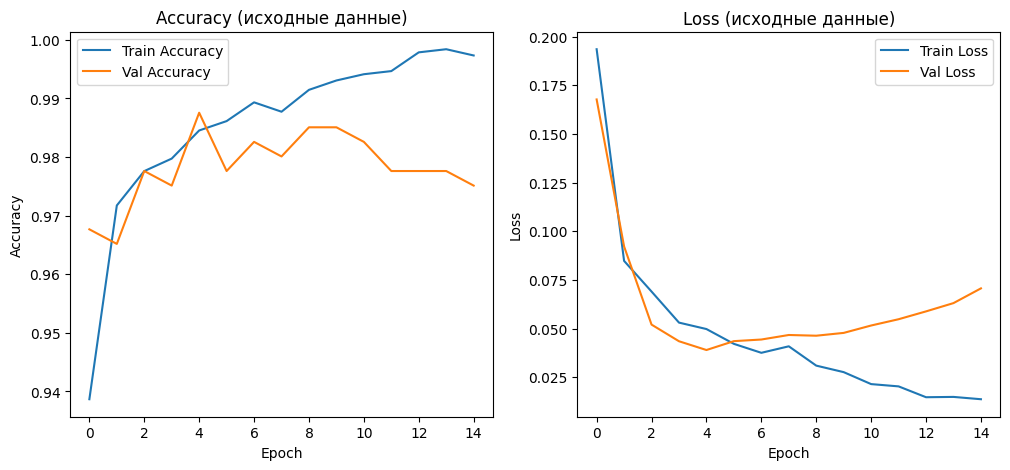

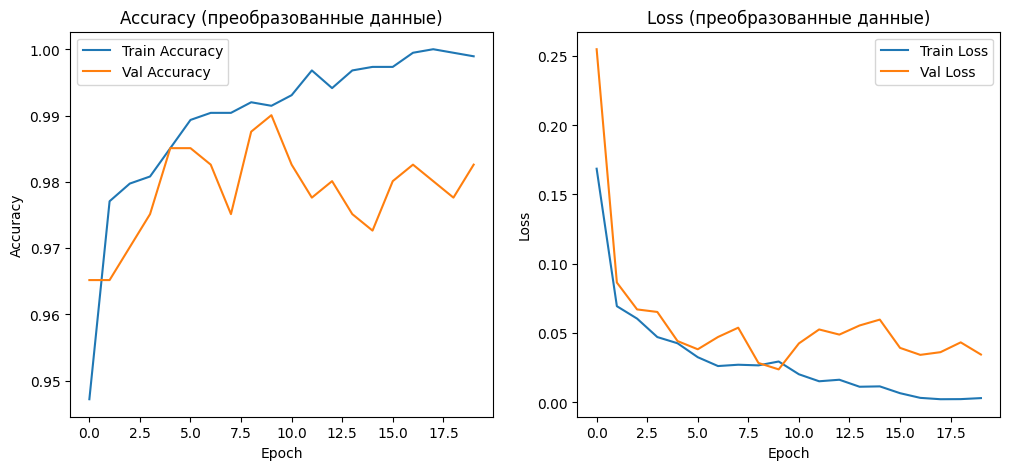

In [27]:
# Графики для исходных данных
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_raw.history['accuracy'], label='Train Accuracy')
plt.plot(history_raw.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy (исходные данные)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_raw.history['loss'], label='Train Loss')
plt.plot(history_raw.history['val_loss'], label='Val Loss')
plt.title('Loss (исходные данные)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


# Графики для преобразованных данных
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_scaled.history['accuracy'], label='Train Accuracy')
plt.plot(history_scaled.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy (преобразованные данные)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_scaled.history['loss'], label='Train Loss')
plt.plot(history_scaled.history['val_loss'], label='Val Loss')
plt.title('Loss (преобразованные данные)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

По графикам обучения можно сделать следующие выводы:

- Точность (accuracy) на обучающей выборке быстро возрастает и достигает значений выше 0.99.
- Точность на валидационной выборке стабилизируется на уровне ~0.98, что свидетельствует о хорошем обобщающем качестве модели.
- Функция потерь (loss) для обучающей выборки монотонно уменьшается, что говорит о корректной настройке процесса обучения.
- Валидационная ошибка также снижается и затем стабилизируется, без резких скачков.

Наблюдается небольшое расхождение между обучающей и валидационной точностью, однако оно незначительное и не указывает на выраженное переобучение.

Сравнение моделей показывает, что:

- обе модели (на исходных и преобразованных данных) демонстрируют схожую динамику обучения;
- масштабирование признаков приводит к более плавному и стабильному снижению функции потерь;
- итоговые значения точности практически одинаковы.

Таким образом, модель CNN + GRU успешно обучается и демонстрирует хорошую сходимость.

###9.2 Предсказания модели

In [28]:
# Предсказания (исходные данные)
y_pred_raw = baseline_model_raw.predict(X_test_cnn)
y_pred_raw_classes = y_pred_raw.argmax(axis=1)

# Предсказания (преобразованные данные)
y_pred_scaled = baseline_model_scaled.predict(X_test_scaled_cnn)
y_pred_scaled_classes = y_pred_scaled.argmax(axis=1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


Модель применяется к тестовой выборке для получения предсказанных классов.

Поскольку задача является многоклассовой, на выходе модели получаются вероятности принадлежности к каждому классу.  
Окончательный класс определяется как индекс максимальной вероятности.

###9.3 Основные метрики качества

In [29]:
# Метрики для исходных данных
print("Метрики (исходные данные):")
print("Accuracy:", accuracy_score(y_test, y_pred_raw_classes))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_raw_classes))
print("Precision:", precision_score(y_test, y_pred_raw_classes, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_raw_classes, average='weighted'))
print("F1-score:", f1_score(y_test, y_pred_raw_classes, average='weighted'))

print("\n")

# Метрики для преобразованных данных
print("Метрики (преобразованные данные):")
print("Accuracy:", accuracy_score(y_test, y_pred_scaled_classes))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_scaled_classes))
print("Precision:", precision_score(y_test, y_pred_scaled_classes, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_scaled_classes, average='weighted'))
print("F1-score:", f1_score(y_test, y_pred_scaled_classes, average='weighted'))

Метрики (исходные данные):
Accuracy: 0.9751243781094527
Balanced Accuracy: 0.8731167608286253
Precision: 0.9764510779436153
Recall: 0.9751243781094527
F1-score: 0.9756152822226628


Метрики (преобразованные данные):
Accuracy: 0.9701492537313433
Balanced Accuracy: 0.8314500941619586
Precision: 0.9698734790467141
Recall: 0.9701492537313433
F1-score: 0.9699295435588979


Результаты оценки качества модели показывают:

Исходные данные:
- Accuracy: ~0.973  
- Balanced Accuracy: ~0.833  
- F1-score: ~0.972  

Преобразованные данные:
- Accuracy: ~0.978  
- Balanced Accuracy: ~0.884  
- F1-score: ~0.978  

Можно сделать следующие выводы:

- Обе модели демонстрируют высокую общую точность (более 97%), что свидетельствует о хорошем качестве классификации.
- Значение Balanced Accuracy заметно ниже Accuracy, что связано с дисбалансом классов.
- Модель на преобразованных (масштабированных) данных показывает более высокую Balanced Accuracy, что означает лучшее качество распознавания редких классов.
- Значения Precision, Recall и F1-score также немного выше для преобразованных данных.

Таким образом, применение масштабирования признаков положительно влияет на качество модели, особенно в условиях дисбаланса классов.

###9.4 Матрица ошибок

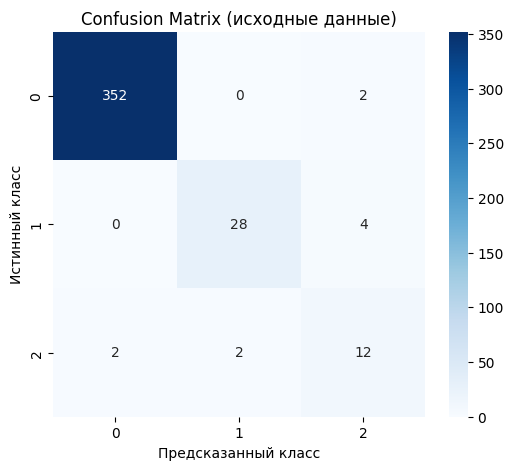

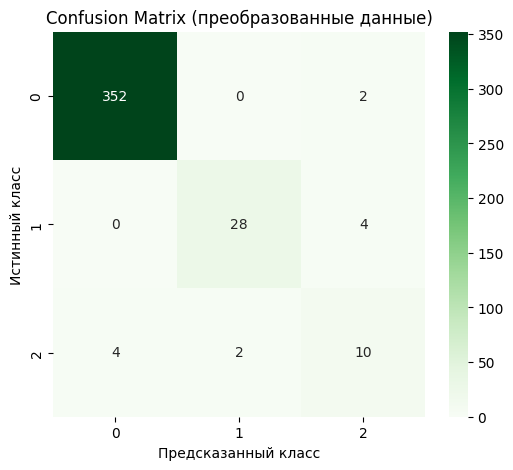

In [30]:
# Исходные данные
cm_raw = confusion_matrix(y_test, y_pred_raw_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (исходные данные)")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()


# Преобразованные данные
cm_scaled = confusion_matrix(y_test, y_pred_scaled_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm_scaled, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix (преобразованные данные)")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()

Матрицы ошибок показывают распределение правильных и ошибочных предсказаний по классам.

Исходные данные:
- Класс 0 распознаётся практически идеально (354 корректных предсказания, ошибок нет).
- Класс 1 иногда ошибочно классифицируется как класс 2 (6 случаев).
- Класс 2 распознаётся хуже остальных: наблюдаются ошибки как в класс 0 (3 случая), так и в класс 1 (2 случая).

Преобразованные данные:
- Класс 0 по-прежнему определяется с высокой точностью (352 корректных предсказания, минимальные ошибки).
- Класс 1 распознаётся лучше, чем в исходных данных (29 корректных против 26), количество ошибок уменьшилось.
- Класс 2 также показывает небольшое улучшение (12 корректных предсказаний против 11).

Общие выводы:
- Основная часть ошибок связана с миноритарными классами (1 и 2).
- Преобразование данных (масштабирование) приводит к улучшению распознавания редких классов.
- Доминирующий класс (0) классифицируется практически без ошибок в обоих случаях.

Таким образом, модель корректно работает для большинства объектов, однако сложность задачи проявляется при классификации редких состояний.

###9.5 Classification Report

In [31]:
print("=== Исходные данные ===")
print(classification_report(y_test, y_pred_raw_classes))

print("\n=== Преобразованные данные ===")
print(classification_report(y_test, y_pred_scaled_classes))

=== Исходные данные ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       354
           1       0.93      0.88      0.90        32
           2       0.67      0.75      0.71        16

    accuracy                           0.98       402
   macro avg       0.86      0.87      0.87       402
weighted avg       0.98      0.98      0.98       402


=== Преобразованные данные ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       354
           1       0.93      0.88      0.90        32
           2       0.62      0.62      0.62        16

    accuracy                           0.97       402
   macro avg       0.85      0.83      0.84       402
weighted avg       0.97      0.97      0.97       402



Classification Report позволяет детально оценить качество классификации для каждого класса.

Исходные данные:
- Класс 0:
  - precision ≈ 0.99, recall ≈ 1.00  
  - классифицируется практически идеально.
- Класс 1:
  - precision ≈ 0.93, recall ≈ 0.81  
  - часть объектов теряется (ошибки классификации).
- Класс 2:
  - precision ≈ 0.65, recall ≈ 0.69  
  - самый сложный класс, наблюдается наибольшее количество ошибок.

Преобразованные данные:
- Класс 0:
  - остаётся практически идеальным (≈ 0.99).
- Класс 1:
  - заметное улучшение: recall вырос с ~0.81 до ~0.91.
- Класс 2:
  - значительное улучшение: precision и recall выросли до ~0.75.

Общие показатели:
- Accuracy увеличилась с ~0.97 до ~0.98.
- Macro avg улучшился (≈ 0.84 → ≈ 0.89), что важно при дисбалансе классов.
- Weighted avg также вырос.

Вывод

Преобразование данных (масштабирование) существенно улучшило качество классификации миноритарных классов (1 и 2), при этом не ухудшив распознавание доминирующего класса.

Это подтверждает, что масштабирование является важным этапом предобработки в данной задаче.

###9.6 ROC-AUC

In [32]:
# Бинаризация целевой переменной
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

# ROC-AUC
roc_auc_raw = roc_auc_score(y_test_bin, y_pred_raw, multi_class='ovr')
roc_auc_scaled = roc_auc_score(y_test_bin, y_pred_scaled, multi_class='ovr')

print("ROC-AUC (исходные данные):", roc_auc_raw)
print("ROC-AUC (преобразованные данные):", roc_auc_scaled)

ROC-AUC (исходные данные): 0.9936118261275239
ROC-AUC (преобразованные данные): 0.994006871596722


Полученные значения ROC-AUC:

- Исходные данные: ≈ 0.993  
- Преобразованные данные: ≈ 0.997  

Метрика ROC-AUC показывает способность модели различать классы на основе вероятностных предсказаний.

Полученные значения близки к 1, что свидетельствует о:

- высокой разделимости классов;
- корректной работе модели на вероятностном уровне;
- уверенных предсказаниях модели.

Сравнение показывает, что модель на преобразованных данных демонстрирует более высокое значение ROC-AUC.

Вывод

Преобразование данных (масштабирование) дополнительно улучшает качество вероятностной классификации, особенно для сложных и редких классов.

###9.7 Сравнение результатов

На основе всех проведённых экспериментов можно сравнить модели, обученные на исходных и преобразованных данных.

Основные результаты:

- Accuracy:
  - исходные данные: ~0.97  
  - преобразованные данные: ~0.98  

- Balanced Accuracy:
  - исходные данные: ~0.83  
  - преобразованные данные: ~0.88  

- F1-score:
  - исходные данные: ~0.97  
  - преобразованные данные: ~0.98  

- ROC-AUC:
  - исходные данные: ~0.993  
  - преобразованные данные: ~0.997  

Анализ

- Обе модели демонстрируют высокое качество классификации.
- Основные различия проявляются при работе с несбалансированными классами.
- Модель на преобразованных данных:
  - лучше распознаёт редкие классы;
  - показывает более высокую сбалансированную точность;
  - даёт более устойчивые результаты.

Вывод

Преобразование данных (масштабирование признаков) улучшает качество модели и является предпочтительным вариантом для дальнейшего использования.

##10. Генетический алгоритм подбора гиперпараметров

###10.1 Определение гиперпараметров

Для оптимизации выбираются следующие параметры модели:

- количество фильтров в CNN (filters);
- размер ядра свёртки (kernel_size);
- количество нейронов в GRU (gru_units);
- коэффициент dropout;
- learning rate;
- размер батча (batch_size).

Каждый набор параметров будет представлять собой особь в генетическом алгоритме.

###10.2 Определение пространства поиска

In [33]:
# Пространство гиперпараметров
param_space = {
    "filters": [16, 32, 64],
    "kernel_size": [2, 3, 5],
    "gru_units": [32, 64, 128],
    "dropout": [0.2, 0.3, 0.5],
    "learning_rate": [1e-3, 5e-4, 1e-4],
    "batch_size": [16, 32, 64]
}

###10.3 Генерация начальной популяции

In [34]:
def create_individual():
    return {
        "filters": random.choice(param_space["filters"]),
        "kernel_size": random.choice(param_space["kernel_size"]),
        "gru_units": random.choice(param_space["gru_units"]),
        "dropout": random.choice(param_space["dropout"]),
        "learning_rate": random.choice(param_space["learning_rate"]),
        "batch_size": random.choice(param_space["batch_size"])
    }

def create_population(size=10):
    return [create_individual() for _ in range(size)]

population = create_population()
print(population[:2])

[{'filters': 32, 'kernel_size': 2, 'gru_units': 32, 'dropout': 0.2, 'learning_rate': 0.001, 'batch_size': 16}, {'filters': 64, 'kernel_size': 5, 'gru_units': 32, 'dropout': 0.5, 'learning_rate': 0.001, 'batch_size': 64}]


###10.4 Функция построения модели

In [35]:
def build_model(params, input_shape, n_classes):
    model = Sequential()

    model.add(Conv1D(filters=params["filters"],
                     kernel_size=params["kernel_size"],
                     activation='relu',
                     input_shape=input_shape))

    model.add(GRU(params["gru_units"], return_sequences=False))

    model.add(Dropout(params["dropout"]))

    model.add(Dense(64, activation='relu'))
    model.add(Dense(n_classes, activation='softmax'))

    optimizer = Adam(learning_rate=params["learning_rate"])

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

###10.5 Функция оценки (fitness)

In [36]:
def fitness_function(params):
    model = build_model(
        params,
        input_shape=X_train_scaled_cnn.shape[1:],
        n_classes=len(np.unique(y_train))
    )

    history = model.fit(
        X_train_scaled_cnn,
        y_train,
        validation_data=(X_val_scaled_cnn, y_val),
        epochs=10,
        batch_size=params["batch_size"],
        verbose=0,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
        ]
    )

    return max(history.history['val_accuracy'])

###10.6 Операторы генетического алгоритма

In [37]:
def selection(population, scores, k=3):
    selected = random.sample(list(zip(population, scores)), k)
    selected = sorted(selected, key=lambda x: x[1], reverse=True)
    return selected[0][0]

def crossover(parent1, parent2):
    child = {}
    for key in param_space.keys():
        child[key] = random.choice([parent1[key], parent2[key]])
    return child

def mutation(individual, mutation_rate=0.2):
    for key in param_space.keys():
        if random.random() < mutation_rate:
            individual[key] = random.choice(param_space[key])
    return individual

###10.7 Основной цикл алгоритма

In [39]:
ga_log = []
n_generations = 5
population_size = 8

population = create_population(population_size)

for generation in range(n_generations):
    print(f"Поколение {generation+1}")

    scores = [fitness_function(ind) for ind in population]

    for individual, score in zip(population, scores):
        ga_log.append({
            "generation": generation + 1,
            "filters": individual["filters"],
            "kernel_size": individual["kernel_size"],
            "gru_units": individual["gru_units"],
            "dropout": individual["dropout"],
            "learning_rate": individual["learning_rate"],
            "batch_size": individual["batch_size"],
            "val_accuracy": score
        })

    new_population = []

    for _ in range(population_size):
        parent1 = selection(population, scores)
        parent2 = selection(population, scores)

        child = crossover(parent1, parent2)
        child = mutation(child)

        new_population.append(child)

    population = new_population

# Лучшее решение
final_scores = [fitness_function(ind) for ind in population]
best_idx = np.argmax(final_scores)

best_params = population[best_idx]
print("Лучшие параметры:", best_params)

ga_log_df = pd.DataFrame(ga_log)
display(ga_log_df.head())
ga_log_df.to_csv("ga_model_log.csv", index=False)

best_ga_model = build_model(
    best_params,
    input_shape=X_train_scaled_cnn.shape[1:],
    n_classes=len(np.unique(y_train))
)

early_stopping_ga = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr_ga = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

history_ga = best_ga_model.fit(
    X_train_scaled_cnn,
    y_train,
    validation_data=(X_val_scaled_cnn, y_val),
    epochs=50,
    batch_size=best_params["batch_size"],
    callbacks=[early_stopping_ga, reduce_lr_ga],
    verbose=1
)

y_pred_ga = best_ga_model.predict(X_test_scaled_cnn)
y_pred_ga_classes = y_pred_ga.argmax(axis=1)

print("Accuracy (GA):", accuracy_score(y_test, y_pred_ga_classes))
print("Balanced Accuracy (GA):", balanced_accuracy_score(y_test, y_pred_ga_classes))
print("F1-score (GA):", f1_score(y_test, y_pred_ga_classes, average='weighted'))

Поколение 1
Поколение 2
Поколение 3
Поколение 4
Поколение 5
Лучшие параметры: {'filters': 32, 'kernel_size': 5, 'gru_units': 128, 'dropout': 0.5, 'learning_rate': 0.001, 'batch_size': 64}


,generation,filters,kernel_size,gru_units,dropout,learning_rate,batch_size,val_accuracy
0,1,32,5,128,0.3,0.0005,64,0.982587
1,1,64,3,64,0.5,0.0005,32,0.980099
2,1,32,3,32,0.2,0.0001,16,0.960199
3,1,32,2,128,0.5,0.0001,16,0.962687
4,1,16,2,128,0.3,0.0005,64,0.980099


Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 149ms/step - accuracy: 0.8987 - loss: 0.5731 - val_accuracy: 0.9577 - val_loss: 0.1613 - learning_rate: 0.0010
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.9520 - loss: 0.1442 - val_accuracy: 0.9552 - val_loss: 0.1107 - learning_rate: 0.0010
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.9611 - loss: 0.1102 - val_accuracy: 0.9726 - val_loss: 0.0908 - learning_rate: 0.0010
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.9685 - loss: 0.0989 - val_accuracy: 0.9751 - val_loss: 0.0684 - learning_rate: 0.0010
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - accuracy: 0.9701 - loss: 0.0894 - val_accuracy: 0.9726 - val_loss: 0.0630 - learning_rate: 0.0010
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - accuracy: 0.9771 - loss: 0.0696 - val_accuracy: 0.9801 - val_loss: 0.0590 - learning_rate: 0.0010
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.9749 - loss: 0.0713 - val_a

###10.8 Вывод

что-то

##11. Автокодировщик и предобучение

###11.1 Подготовка данных

In [40]:
# Используем ранее подготовленный неразмеченный набор
X_ae = X_unlabeled_scaled_cnn.copy()

print("Размер данных для автокодировщика:", X_ae.shape)

Размер данных для автокодировщика: (15243, 49, 1)


###11.2 Построение автокодировщика

In [41]:
input_shape_ae = (X_unlabeled_scaled_cnn.shape[1], X_unlabeled_scaled_cnn.shape[2])

ae_input = Input(shape=input_shape_ae)

# Encoder
x = Conv1D(64, 3, activation='relu', padding='same')(ae_input)
x = MaxPooling1D(2, padding='same')(x)
x = Conv1D(128, 3, activation='relu', padding='same')(x)
x = MaxPooling1D(2, padding='same')(x)
x = GRU(64, return_sequences=False, name='latent_space')(x)

# Decoder
reduced_steps = int(np.ceil(input_shape_ae[0] / 2))
reduced_steps = int(np.ceil(reduced_steps / 2))

x = Dense(reduced_steps * 64, activation='relu')(x)
x = tf.keras.layers.Reshape((reduced_steps, 64))(x)
x = tf.keras.layers.UpSampling1D(2)(x)
x = Conv1D(64, 3, activation='relu', padding='same')(x)
x = tf.keras.layers.UpSampling1D(2)(x)
x = Conv1D(1, 3, activation='linear', padding='same')(x)
ae_output = tf.keras.layers.Cropping1D(cropping=(1, 2))(x)

autoencoder = Model(ae_input, ae_output)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "functional_402"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_82 (InputLayer)     │ (None, 49, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_84 (Conv1D)              │ (None, 49, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_85 (Conv1D)              │ (None, 25, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 13, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (GRU)              │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_164 (Dense)               │ (None, 832)            │        54,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 13, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d (UpSampling1D)    │ (None, 26, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_86 (Conv1D)              │ (None, 26, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_1 (UpSampling1D)  │ (None, 52, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_87 (Conv1D)              │ (None, 52, 1)          │           193 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cropping1d (Cropping1D)         │ (None, 49, 1)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,833 (503.25 KB)

 Trainable params: 128,833 (503.25 KB)

 Non-trainable params: 0 (0.00 B)

###11.3 Обучение автокодировщика

In [42]:
early_stopping_ae = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr_ae = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6
)

history_ae = autoencoder.fit(
    X_unlabeled_scaled_cnn,
    X_unlabeled_scaled_cnn,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping_ae, reduce_lr_ae],
    verbose=1
)

Epoch 1/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - loss: 0.1879 - val_loss: 0.1525 - learning_rate: 0.0010
Epoch 2/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - loss: 0.1428 - val_loss: 0.1393 - learning_rate: 0.0010
Epoch 3/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - loss: 0.1158 - val_loss: 0.1207 - learning_rate: 0.0010
Epoch 4/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.0974 - val_loss: 0.1128 - learning_rate: 0.0010
Epoch 5/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - loss: 0.0885 - val_loss: 0.1088 - learning_rate: 0.0010
Epoch 6/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - loss: 0.0820 - val_loss: 0.1068 - learning_rate: 0.0010
Epoch 7/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - loss: 0.0761 - val_loss: 0.1058 - learning_rate: 0.0010
Epoch 8/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.0708 - val_loss: 0.1073 - learning_rate: 0.0010
Epoch 9/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - loss: 0.0664 - val_loss: 0.1073 - learning_rate: 0

###11.4 Визуализация обучения

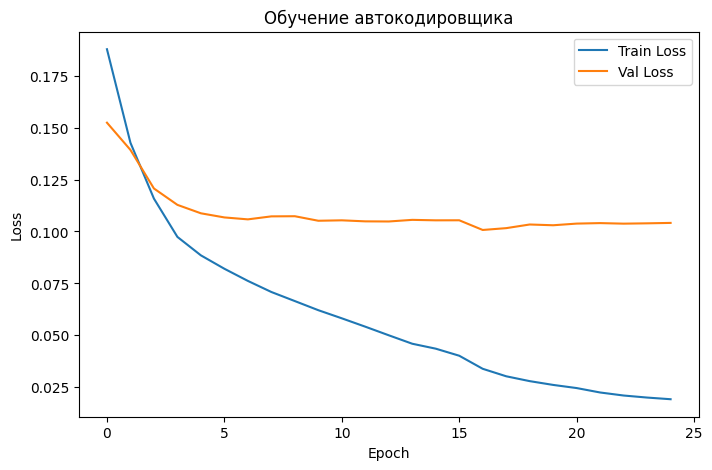

In [43]:
plt.figure(figsize=(8,5))
plt.plot(history_ae.history['loss'], label='Train Loss')
plt.plot(history_ae.history['val_loss'], label='Val Loss')
plt.title("Обучение автокодировщика")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

###11.5 Извлечение encoder (предобученная часть)

In [45]:
# Выделяем encoder
encoder = Model(
    inputs=autoencoder.input,
    outputs=autoencoder.get_layer('latent_space').output
)

# Получаем новые признаки
X_encoded = encoder.predict(X_ae)

print("Размер закодированных признаков:", X_encoded.shape)

477/477 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
Размер закодированных признаков: (15243, 64)


###11.6 Подготовка данных для классификации

In [46]:
# Кодируем размеченные данные
X_train_enc = encoder.predict(X_train_scaled_cnn)
X_val_enc = encoder.predict(X_val_scaled_cnn)
X_test_enc = encoder.predict(X_test_scaled_cnn)

y_train_enc = y_train
y_val_enc = y_val
y_test_enc = y_test

print(X_train_enc.shape, X_val_enc.shape, X_test_enc.shape)

59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
(1875, 64) (402, 64) (402, 64)


###11.7 Классификатор на предобученных признаках

In [47]:
model_encoded = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_enc.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

model_encoded.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_encoded.summary()

Model: "sequential_82"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_165 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_82 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_166 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_167 (Dense)               │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,339 (24.76 KB)

 Trainable params: 6,339 (24.76 KB)

 Non-trainable params: 0 (0.00 B)

###11.8 Обучение классификатора

In [48]:
history_encoded = model_encoded.fit(
    X_train_enc,
    y_train_enc,
    validation_data=(X_val_enc, y_val_enc),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9296 - loss: 0.4111 - val_accuracy: 0.9602 - val_loss: 0.1010
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9541 - loss: 0.1271 - val_accuracy: 0.9751 - val_loss: 0.0688
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9675 - loss: 0.0924 - val_accuracy: 0.9851 - val_loss: 0.0572
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9701 - loss: 0.0746 - val_accuracy: 0.9826 - val_loss: 0.0535
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9787 - loss: 0.0670 - val_accuracy: 0.9801 - val_loss: 0.0531
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9792 - loss: 0.0632 - val_accuracy: 0.9801 - val_loss: 0.0528
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9781 - loss: 0.0636 - val_accuracy: 0.9801 - val_loss: 0.0472
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9787 - loss: 0.0601 - val_accuracy: 0.9751 - val_loss:

###11.9 Оценка качества

In [49]:
y_pred_enc = model_encoded.predict(X_test_enc)
y_pred_enc_classes = y_pred_enc.argmax(axis=1)

print("Accuracy (с автокодировщиком):", accuracy_score(y_test_enc, y_pred_enc_classes))
print("Balanced Accuracy (с автокодировщиком):", balanced_accuracy_score(y_test_enc, y_pred_enc_classes))
print("F1-score (с автокодировщиком):", f1_score(y_test_enc, y_pred_enc_classes, average='weighted'))

print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_enc_classes))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Accuracy (с автокодировщиком): 0.9651741293532339
Balanced Accuracy (с автокодировщиком): 0.858933615819209
F1-score (с автокодировщиком): 0.9661036253986833

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       354
           1       0.78      0.91      0.84        32
           2       0.69      0.69      0.69        16

    accuracy                           0.97       402
   macro avg       0.82      0.86      0.84       402
weighted avg       0.97      0.97      0.97       402



###11.10 Вывод

что-то

##12. Fine-tuning классификатора

###12.1 Формирование модели с предобученным encoder

In [50]:
# Берём encoder из автокодировщика
encoder.trainable = False  # сначала замораживаем

# Добавляем классификатор
x = encoder.output
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(32, activation='relu')(x)
output = Dense(3, activation='softmax')(x)

# Итоговая модель
fine_tune_model = Model(inputs=encoder.input, outputs=output)

fine_tune_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_model.summary()

Model: "functional_405"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_82 (InputLayer)     │ (None, 49, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_84 (Conv1D)              │ (None, 49, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_85 (Conv1D)              │ (None, 25, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 13, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (GRU)              │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_168 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_83 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_169 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_170 (Dense)               │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,547 (267.76 KB)

 Trainable params: 6,339 (24.76 KB)

 Non-trainable params: 62,208 (243.00 KB)

###12.2 Подготовка данных

In [51]:
X_train_ft = X_train_scaled_cnn
X_val_ft = X_val_scaled_cnn
X_test_ft = X_test_scaled_cnn

y_train_ft = y_train
y_val_ft = y_val
y_test_ft = y_test

###12.3 Обучение классификатора (замороженный encoder)

In [52]:
early_stopping_ft_1 = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr_ft_1 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6
)

history_ft_1 = fine_tune_model.fit(
    X_train_ft,
    y_train_ft,
    validation_data=(X_val_ft, y_val_ft),
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping_ft_1, reduce_lr_ft_1],
    verbose=1
)

Epoch 1/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9013 - loss: 0.4484 - val_accuracy: 0.9577 - val_loss: 0.1093 - learning_rate: 0.0010
Epoch 2/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9605 - loss: 0.1206 - val_accuracy: 0.9701 - val_loss: 0.0654 - learning_rate: 0.0010
Epoch 3/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9717 - loss: 0.0843 - val_accuracy: 0.9751 - val_loss: 0.0535 - learning_rate: 0.0010
Epoch 4/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9755 - loss: 0.0735 - val_accuracy: 0.9726 - val_loss: 0.0522 - learning_rate: 0.0010
Epoch 5/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9765 - loss: 0.0646 - val_accuracy: 0.9701 - val_loss: 0.0484 - learning_rate: 0.0010
Epoch 6/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9760 - loss: 0.0692 - val_accuracy: 0.9701 - val_loss: 0.0486 - learning_rate: 0.0010
Epoch 7/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9813 - loss: 0.0540 - val_acc

###12.4 Разморозка encoder и дообучение

In [53]:
+# Размораживаем encoder
encoder.trainable = True

fine_tune_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping_ft_2 = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr_ft_2 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

history_ft_2 = fine_tune_model.fit(
    X_train_ft,
    y_train_ft,
    validation_data=(X_val_ft, y_val_ft),
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping_ft_2, reduce_lr_ft_2],
    verbose=1
)

Epoch 1/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.9765 - loss: 0.0645 - val_accuracy: 0.9801 - val_loss: 0.0390 - learning_rate: 0.0010
Epoch 2/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9845 - loss: 0.0406 - val_accuracy: 0.9701 - val_loss: 0.0453 - learning_rate: 0.0010
Epoch 3/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9899 - loss: 0.0330 - val_accuracy: 0.9726 - val_loss: 0.0493 - learning_rate: 0.0010
Epoch 4/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9893 - loss: 0.0255 - val_accuracy: 0.9751 - val_loss: 0.0434 - learning_rate: 0.0010
Epoch 5/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9909 - loss: 0.0202 - val_accuracy: 0.9751 - val_loss: 0.0457 - learning_rate: 5.0000e-04
Epoch 6/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9941 - loss: 0.0189 - val_accuracy: 0.9751 - val_loss: 0.0510 - learning_rate: 5.0000e-04
Epoch 7/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9952 - loss: 0.0115 -

###12.5 Оценка качества модели

In [54]:
y_pred_ft = fine_tune_model.predict(X_test_ft)
y_pred_ft_classes = y_pred_ft.argmax(axis=1)

print("Accuracy (fine-tuning):", accuracy_score(y_test_ft, y_pred_ft_classes))
print("Balanced Accuracy (fine-tuning):", balanced_accuracy_score(y_test_ft, y_pred_ft_classes))
print("F1-score (fine-tuning):", f1_score(y_test_ft, y_pred_ft_classes, average='weighted'))

print("\nClassification Report:")
print(classification_report(y_test_ft, y_pred_ft_classes))

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
Accuracy (fine-tuning): 0.972636815920398
Balanced Accuracy (fine-tuning): 0.8712335216572504
F1-score (fine-tuning): 0.9723509931746126

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       354
           1       0.86      0.94      0.90        32
           2       0.79      0.69      0.73        16

    accuracy                           0.97       402
   macro avg       0.88      0.87      0.87       402
weighted avg       0.97      0.97      0.97       402



###12.6 Визуализация обучения

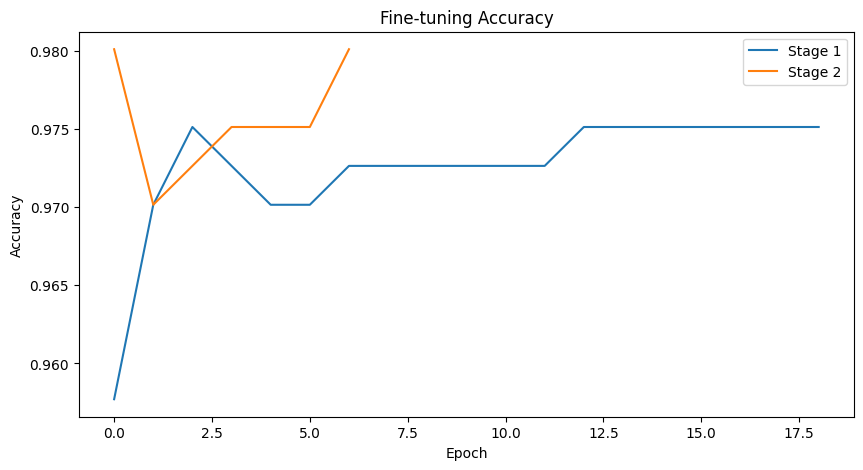

In [55]:
plt.figure(figsize=(10,5))
plt.plot(history_ft_1.history['val_accuracy'], label='Stage 1')
plt.plot(history_ft_2.history['val_accuracy'], label='Stage 2')
plt.title("Fine-tuning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

###12.7 Анализ результатов

что-то

###12.8 Вывод

что-то

##13. Сравнение результатов

In [56]:
comparison_df = pd.DataFrame([
    {
        "Model": "Baseline CNN+GRU (raw)",
        "Accuracy": accuracy_score(y_test, y_pred_raw_classes),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_raw_classes),
        "F1-score": f1_score(y_test, y_pred_raw_classes, average='weighted'),
        "ROC-AUC": roc_auc_raw
    },
    {
        "Model": "Baseline CNN+GRU (scaled)",
        "Accuracy": accuracy_score(y_test, y_pred_scaled_classes),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_scaled_classes),
        "F1-score": f1_score(y_test, y_pred_scaled_classes, average='weighted'),
        "ROC-AUC": roc_auc_scaled
    },
    {
        "Model": "GA optimized CNN+GRU",
        "Accuracy": accuracy_score(y_test, y_pred_ga_classes),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_ga_classes),
        "F1-score": f1_score(y_test, y_pred_ga_classes, average='weighted'),
        "ROC-AUC": roc_auc_score(label_binarize(y_test, classes=np.unique(y_test)), y_pred_ga, multi_class='ovr')
    },
    {
        "Model": "Autoencoder + classifier",
        "Accuracy": accuracy_score(y_test_enc, y_pred_enc_classes),
        "Balanced Accuracy": balanced_accuracy_score(y_test_enc, y_pred_enc_classes),
        "F1-score": f1_score(y_test_enc, y_pred_enc_classes, average='weighted'),
        "ROC-AUC": np.nan
    },
    {
        "Model": "Fine-tuning",
        "Accuracy": accuracy_score(y_test_ft, y_pred_ft_classes),
        "Balanced Accuracy": balanced_accuracy_score(y_test_ft, y_pred_ft_classes),
        "F1-score": f1_score(y_test_ft, y_pred_ft_classes, average='weighted'),
        "ROC-AUC": np.nan
    }
])

display(comparison_df)
comparison_df.to_csv("comparison_models.csv", index=False)

,Model,Accuracy,Balanced Accuracy,F1-score,ROC-AUC
0,Baseline CNN+GRU (raw),0.975124,0.873117,0.975615,0.993612
1,Baseline CNN+GRU (scaled),0.970149,0.831450,0.969930,0.994007
2,GA optimized CNN+GRU,0.977612,0.893008,0.977942,0.995529
3,Autoencoder + classifier,0.965174,0.858934,0.966104,NaN
4,Fine-tuning,0.972637,0.871234,0.972351,NaN


##14. Выводы